In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

XGB_MODEL_PATH = 'xgb_model.pkl'
DATA_PATH = 'processed_player_data.csv'

model = joblib.load(XGB_MODEL_PATH)
df = pd.read_csv(DATA_PATH)

feature_cols = [
    'batsman_avg',
    'historical_sr',
    'balls_faced_avg',
    'avg_vs_opp',
    'venue_encoded',
    'opp_strength',
    'home_advantage',
    'season_year'
]

X = df[feature_cols].dropna()
print("Rows for SHAP:", len(X))

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

Rows for SHAP: 10306


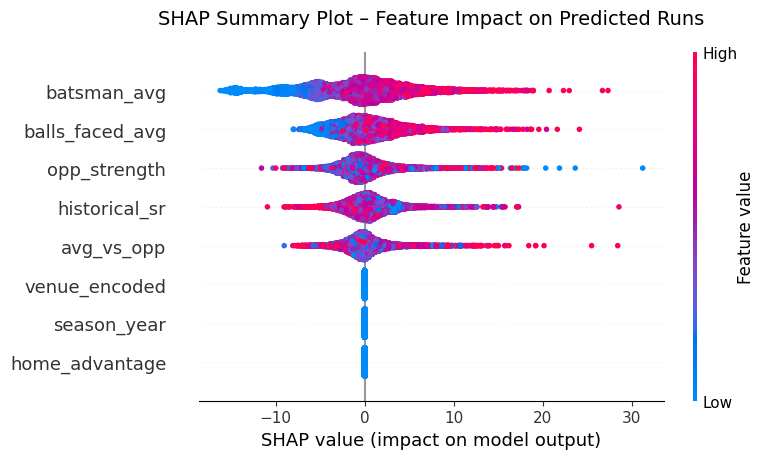

In [2]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X,
    plot_type="dot",
    show=False,
    max_display=10
)
plt.title("SHAP Summary Plot – Feature Impact on Predicted Runs", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()

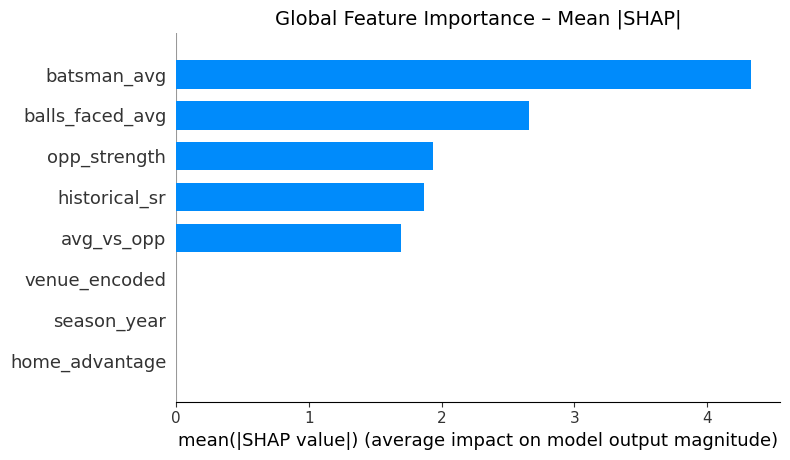

In [3]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    max_display=10,
    show=False
)
plt.title("Global Feature Importance – Mean |SHAP|", fontsize=14)
plt.tight_layout()
plt.savefig("shap_bar_importance.png", dpi=200, bbox_inches="tight")
plt.show()

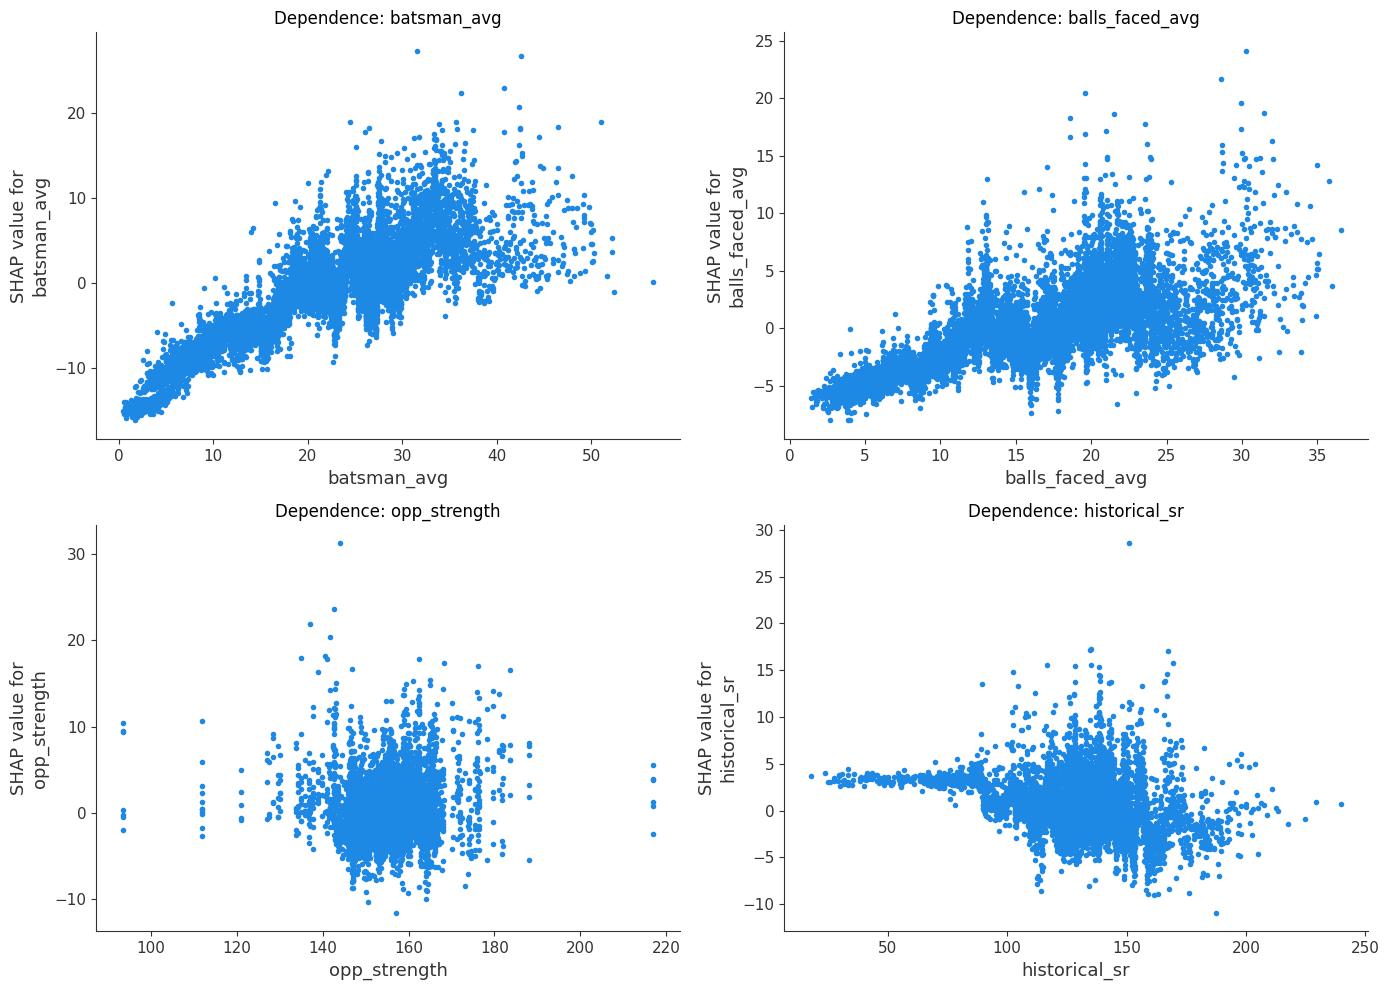

In [4]:
top_features = pd.Series(np.abs(shap_values).mean(0), index=feature_cols).sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(top_features):
    shap.dependence_plot(
        col,
        shap_values,
        X,
        interaction_index=None,
        show=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Dependence: {col}", fontsize=12)

plt.tight_layout()
plt.savefig("shap_dependence_top4.png", dpi=180, bbox_inches="tight")
plt.show()


Low prediction example (index 6197)


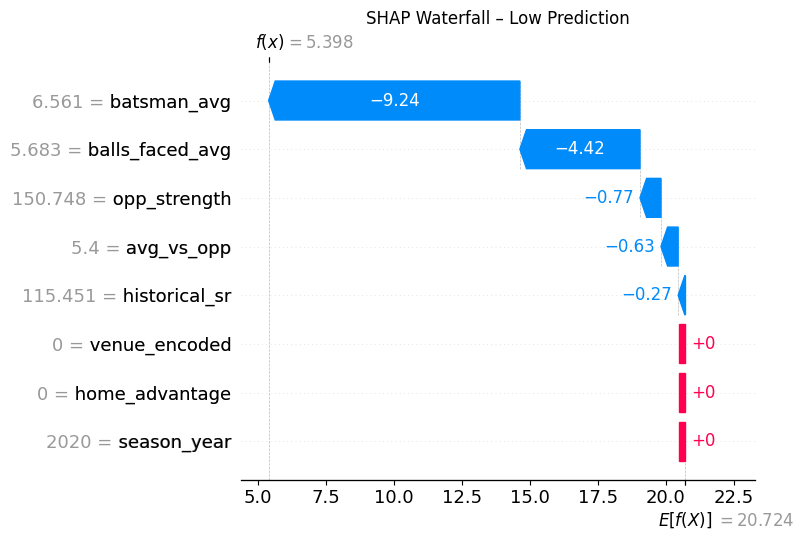


Medium prediction example (index 521)


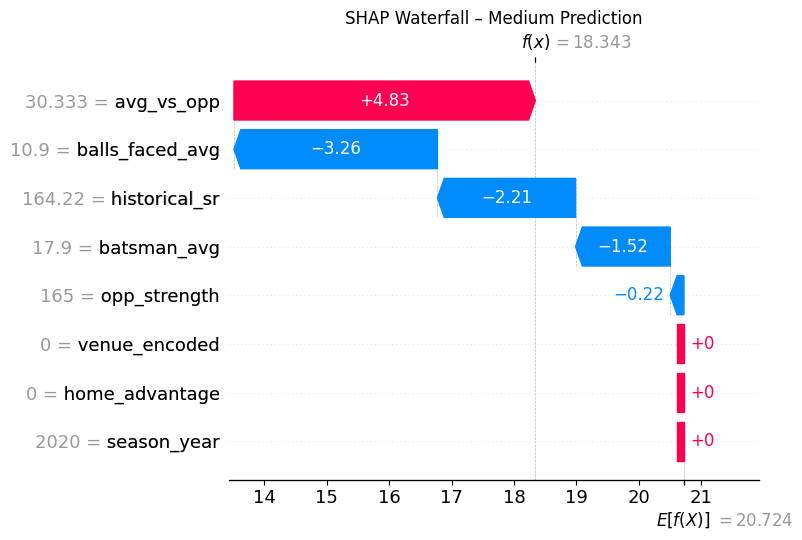


High prediction example (index 6285)


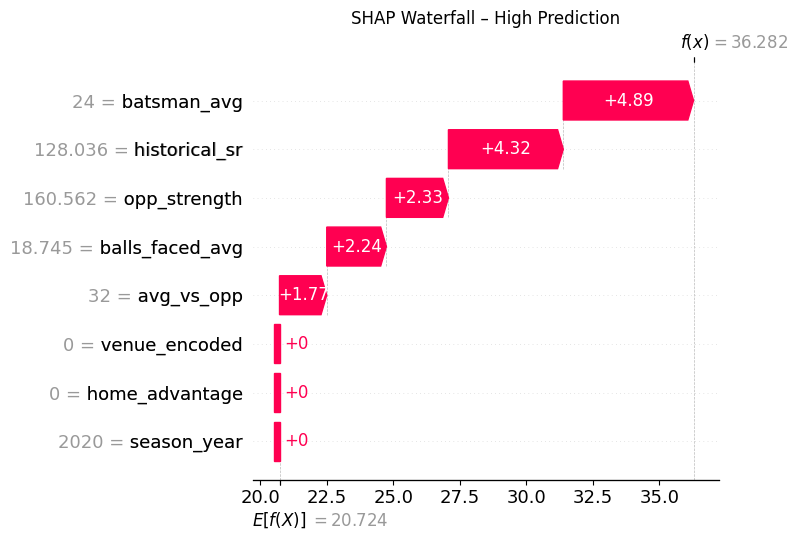

In [5]:
sorted_idx = np.argsort(model.predict(X))

examples = {
    "Low": sorted_idx[len(sorted_idx)//20],
    "Medium": sorted_idx[len(sorted_idx)//2],
    "High": sorted_idx[-len(sorted_idx)//10]
}

for label, idx in examples.items():
    print(f"\n{label} prediction example (index {idx})")

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X.iloc[idx],
            feature_names=feature_cols
        ),
        max_display=12,
        show=False
    )
    plt.title(f"SHAP Waterfall – {label} Prediction")
    plt.tight_layout()
    plt.savefig(f"shap_waterfall_{label.lower()}.png", dpi=180, bbox_inches="tight")
    plt.show()

In [6]:
report = f"""
# IPL Batsman Runs Prediction – SHAP Analysis Report

**Model**: XGBoost
**Dataset size for explanation**: {len(X):,} innings
**Expected value (average prediction)**: {explainer.expected_value:.1f} runs

## Global Feature Importance (mean |SHAP value|)
"""

importance = pd.Series(np.abs(shap_values).mean(0), index=feature_cols).sort_values(ascending=False)
print(report)
print(importance.round(4))

print("\nTop drivers:")
print("1. batsman_avg      → strongest signal, past form dominates")
print("2. avg_vs_opp       → matchup history very important")
print("3. opp_strength     → easier bowling attacks → higher expected runs")
print("4. historical_sr    → aggression level matters, non-linear effect")
print("5. venue_encoded    → pitch/ground characteristics matter")
print("6–8. lower impact   → season_year, home_advantage, balls_faced_avg")

print("\nFiles created:")
print("• shap_summary_beeswarm.png")
print("• shap_bar_importance.png")
print("• shap_dependence_top4.png")
print("• shap_waterfall_low.png / medium.png / high.png")


# IPL Batsman Runs Prediction – SHAP Analysis Report

**Model**: XGBoost  
**Dataset size for explanation**: 10,306 innings  
**Expected value (average prediction)**: 20.7 runs

## Global Feature Importance (mean |SHAP value|)

batsman_avg        4.3309
balls_faced_avg    2.6602
opp_strength       1.9376
historical_sr      1.8643
avg_vs_opp         1.6951
venue_encoded      0.0000
home_advantage     0.0000
season_year        0.0000
dtype: float32

Top drivers:
1. batsman_avg      → strongest signal, past form dominates
2. avg_vs_opp       → matchup history very important
3. opp_strength     → easier bowling attacks → higher expected runs
4. historical_sr    → aggression level matters, non-linear effect
5. venue_encoded    → pitch/ground characteristics matter
6–8. lower impact   → season_year, home_advantage, balls_faced_avg

Files created:
• shap_summary_beeswarm.png
• shap_bar_importance.png
• shap_dependence_top4.png
• shap_waterfall_low.png / medium.png / high.png
